In [60]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [22]:
url="https://archive-api.open-meteo.com/v1/archive?latitude=31.5497&longitude=74.3436&start_date=2020-01-01&end_date=2025-01-01&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode&timezone=auto"
responce=requests.get(url)
response = requests.get(url)
print(response.text)
df=pd.DataFrame(responce.json()['hourly'])



{"latitude":31.528997,"longitude":74.38995,"generationtime_ms":8.625268936157227,"utc_offset_seconds":18000,"timezone":"Asia/Karachi","timezone_abbreviation":"GMT+5","elevation":222.0,"hourly_units":{"time":"iso8601","temperature_2m":"°C","relative_humidity_2m":"%","precipitation":"mm","wind_speed_10m":"km/h","weathercode":"wmo code"},"hourly":{"time":["2020-01-01T00:00","2020-01-01T01:00","2020-01-01T02:00","2020-01-01T03:00","2020-01-01T04:00","2020-01-01T05:00","2020-01-01T06:00","2020-01-01T07:00","2020-01-01T08:00","2020-01-01T09:00","2020-01-01T10:00","2020-01-01T11:00","2020-01-01T12:00","2020-01-01T13:00","2020-01-01T14:00","2020-01-01T15:00","2020-01-01T16:00","2020-01-01T17:00","2020-01-01T18:00","2020-01-01T19:00","2020-01-01T20:00","2020-01-01T21:00","2020-01-01T22:00","2020-01-01T23:00","2020-01-02T00:00","2020-01-02T01:00","2020-01-02T02:00","2020-01-02T03:00","2020-01-02T04:00","2020-01-02T05:00","2020-01-02T06:00","2020-01-02T07:00","2020-01-02T08:00","2020-01-02T09:00"

In [23]:
df

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode
0,2020-01-01T00:00,2.1,100,0.0,8.4,3
1,2020-01-01T01:00,2.0,100,0.0,6.6,3
2,2020-01-01T02:00,2.5,100,0.0,5.8,3
3,2020-01-01T03:00,2.5,100,0.0,6.8,3
4,2020-01-01T04:00,2.4,100,0.0,5.1,3
...,...,...,...,...,...,...
43867,2025-01-01T19:00,11.0,89,0.0,1.6,0
43868,2025-01-01T20:00,10.0,92,0.0,1.8,1
43869,2025-01-01T21:00,9.4,94,0.0,1.3,2
43870,2025-01-01T22:00,9.1,95,0.0,1.9,3


In [24]:
df.shape

(43872, 6)

In [26]:
df.isnull()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
43867,False,False,False,False,False,False
43868,False,False,False,False,False,False
43869,False,False,False,False,False,False
43870,False,False,False,False,False,False


In [27]:
df.drop_duplicates()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode
0,2020-01-01T00:00,2.1,100,0.0,8.4,3
1,2020-01-01T01:00,2.0,100,0.0,6.6,3
2,2020-01-01T02:00,2.5,100,0.0,5.8,3
3,2020-01-01T03:00,2.5,100,0.0,6.8,3
4,2020-01-01T04:00,2.4,100,0.0,5.1,3
...,...,...,...,...,...,...
43867,2025-01-01T19:00,11.0,89,0.0,1.6,0
43868,2025-01-01T20:00,10.0,92,0.0,1.8,1
43869,2025-01-01T21:00,9.4,94,0.0,1.3,2
43870,2025-01-01T22:00,9.1,95,0.0,1.9,3


In [45]:
df['time']=pd.to_datetime(df['time'])
df['Year']=df['time'].dt.year

df['month']=df['time'].dt.month
df['Day']=df['time'].dt.day
df['hour']=df['time'].dt.hour

In [46]:
df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode,Year,month,Day,hour
0,2020-01-01 00:00:00,2.1,100,0.0,8.4,3,2020,1,1,0
1,2020-01-01 01:00:00,2.0,100,0.0,6.6,3,2020,1,1,1
2,2020-01-01 02:00:00,2.5,100,0.0,5.8,3,2020,1,1,2
3,2020-01-01 03:00:00,2.5,100,0.0,6.8,3,2020,1,1,3
4,2020-01-01 04:00:00,2.4,100,0.0,5.1,3,2020,1,1,4


In [50]:
def get_season(month):
    if month in [12,1,2]:
        return("winters")
    elif month in [3,4,5]:
        return("spring")
    elif month in [6,7,8]:
        return("summer")
    else:
        return("Autumn")

df['season']=df['month'].apply(get_season)

In [51]:
df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode,Year,month,Day,hour,season
0,2020-01-01 00:00:00,2.1,100,0.0,8.4,3,2020,1,1,0,winters
1,2020-01-01 01:00:00,2.0,100,0.0,6.6,3,2020,1,1,1,winters
2,2020-01-01 02:00:00,2.5,100,0.0,5.8,3,2020,1,1,2,winters
3,2020-01-01 03:00:00,2.5,100,0.0,6.8,3,2020,1,1,3,winters
4,2020-01-01 04:00:00,2.4,100,0.0,5.1,3,2020,1,1,4,winters


In [55]:
WMO_CODES={
        0:'Clear sky',1:'Mainly clear',2:'Partly cloudy',
    3:'Overcast',61:'Slight rain',63:'Moderate rain',
    71:'Slight snow',80:'Showers',95:'Thunderstorm'
}
df['weather_Description']=df['weathercode'].map(WMO_CODES)

In [56]:
df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode,Year,month,Day,hour,season,weather_Description
0,2020-01-01 00:00:00,2.1,100,0.0,8.4,3,2020,1,1,0,winters,Overcast
1,2020-01-01 01:00:00,2.0,100,0.0,6.6,3,2020,1,1,1,winters,Overcast
2,2020-01-01 02:00:00,2.5,100,0.0,5.8,3,2020,1,1,2,winters,Overcast
3,2020-01-01 03:00:00,2.5,100,0.0,6.8,3,2020,1,1,3,winters,Overcast
4,2020-01-01 04:00:00,2.4,100,0.0,5.1,3,2020,1,1,4,winters,Overcast


In [57]:
df.to_csv("lahore_weather_2020_2025.csv",index=False)

In [58]:
df.shape

(43872, 12)

In [59]:
df.isnull()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,weathercode,Year,month,Day,hour,season,weather_Description
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
43867,False,False,False,False,False,False,False,False,False,False,False,False
43868,False,False,False,False,False,False,False,False,False,False,False,False
43869,False,False,False,False,False,False,False,False,False,False,False,False
43870,False,False,False,False,False,False,False,False,False,False,False,False


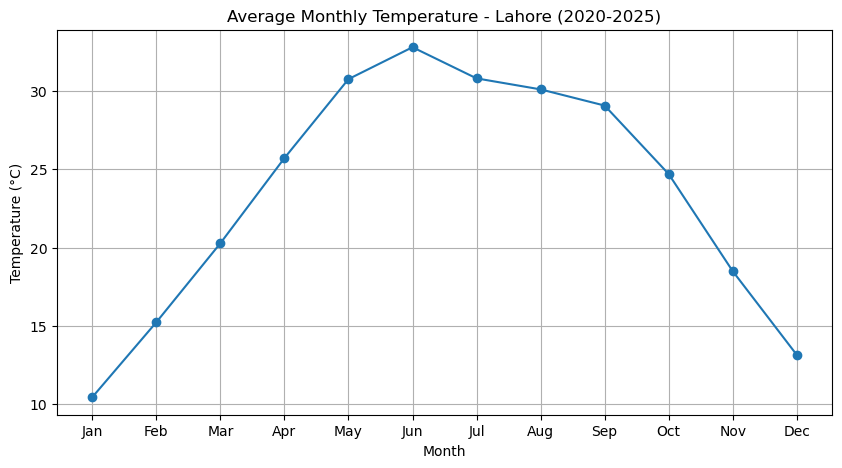

In [65]:
monthly_temp=df.groupby('month')['temperature_2m'].mean()
plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker='o') 
plt.title('Average Monthly Temperature - Lahore (2020-2025)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.show()

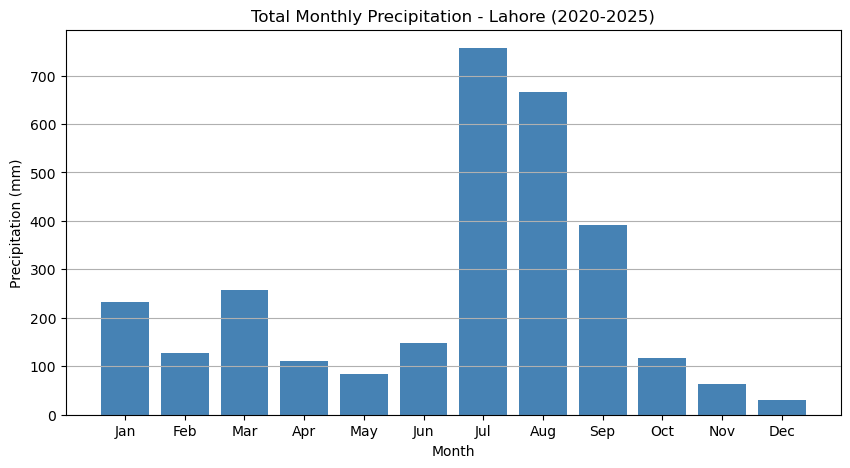

In [66]:
monthly_rain = df.groupby('month')['precipitation'].sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain.values, color='steelblue')
plt.title('Total Monthly Precipitation - Lahore (2020-2025)')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y')
plt.show()

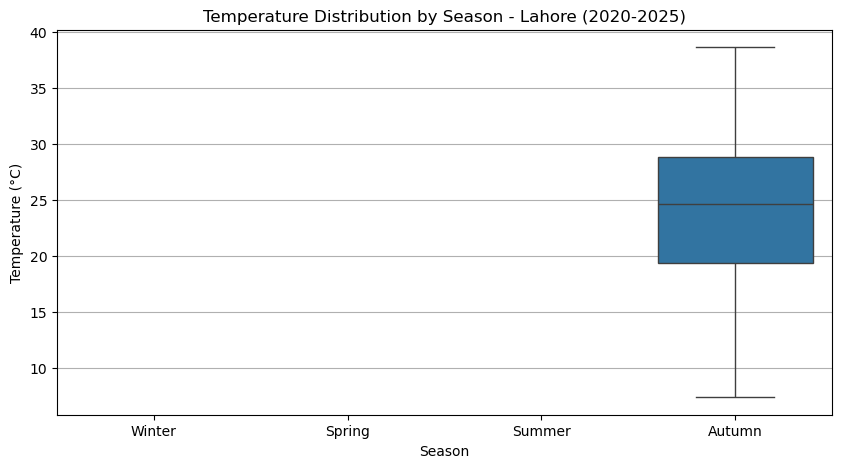

In [67]:
import seaborn as sns

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='season', y='temperature_2m', order=season_order)
plt.title('Temperature Distribution by Season - Lahore (2020-2025)')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y')
plt.show()

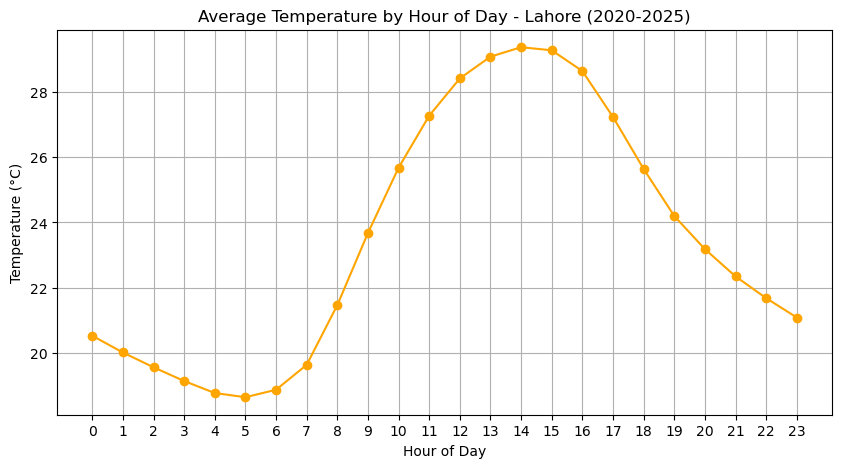

In [68]:
hourly_temp = df.groupby('hour')['temperature_2m'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_temp.index, hourly_temp.values, marker='o', color='orange')
plt.title('Average Temperature by Hour of Day - Lahore (2020-2025)')
plt.xlabel('Hour of Day')
plt.ylabel('Temperature (°C)')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

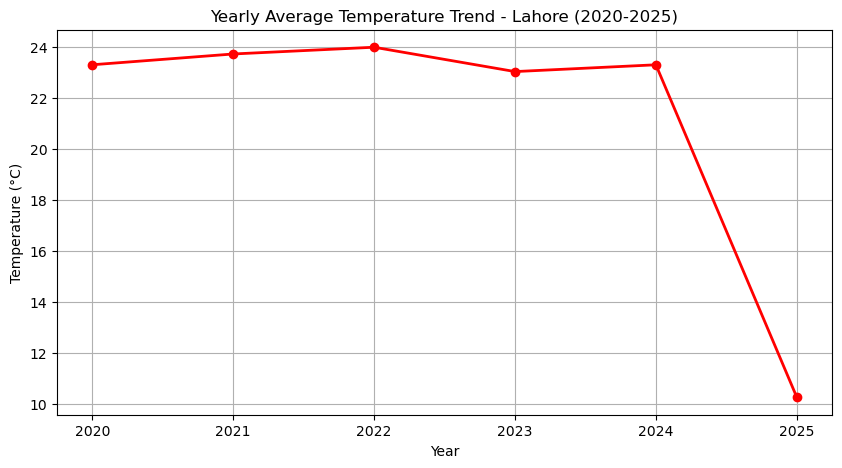

In [70]:
yearly_temp = df.groupby('Year')['temperature_2m'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_temp.index, yearly_temp.values, marker='o', color='red', linewidth=2)
plt.title('Yearly Average Temperature Trend - Lahore (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.xticks(yearly_temp.index)
plt.grid(True)
plt.show()

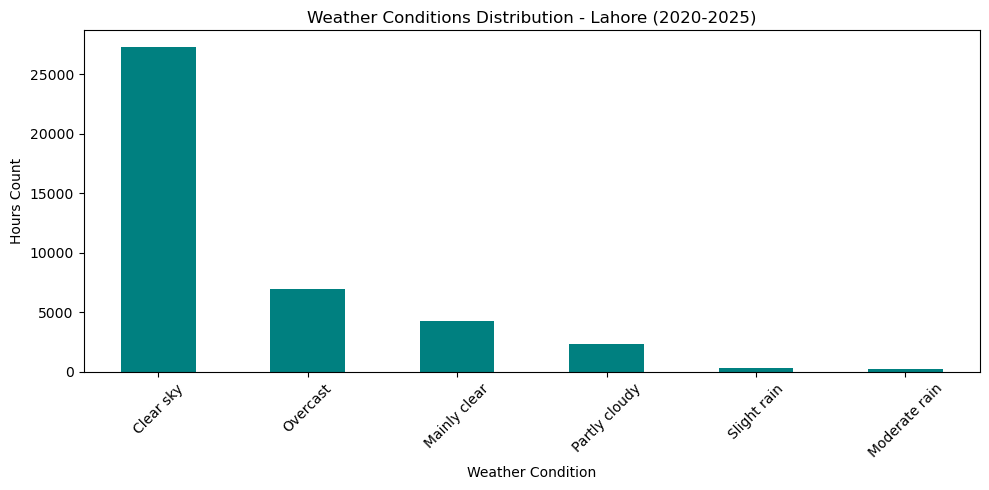

In [72]:
plt.figure(figsize=(10,5))
df['weather_Description'].value_counts().plot(kind='bar', color='teal')
plt.title('Weather Conditions Distribution - Lahore (2020-2025)')
plt.xlabel('Weather Condition')
plt.ylabel('Hours Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()